In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn import set_config

In [3]:
set_config(transform_output="pandas")

In [4]:
df = pd.read_csv("../data/customer_churn_processed_data.csv")
df.info()

FileNotFoundError: [Errno 2] No such file or directory: '../data/customer_churn_processed_data.csv'

### Split the data

In [ ]:
X = df.drop("exited", axis=1)
y = df["exited"]

### Create feature transformer

In [ ]:
numeric_cols = ["creditscore", "age", "tenure", "balance", "numofproducts", "estimatedsalary"]
cat_cols = ["gender", "country"]
preprocessor = ColumnTransformer(
    [
        ("cat", OneHotEncoder(sparse_output=False, drop="if_binary"), cat_cols),
        # ("scaler", StandardScaler(), numeric_cols)
    ],
    remainder="passthrough"
)
X_processed = preprocessor.fit_transform(X)
X_processed.head()

In [ ]:
X_processed_scaled = StandardScaler().fit_transform(X_processed)

### Build kmeans model

In [ ]:
inertias = []
sl_scores = []
n_clusters = range(2, 20)

for n_cluster in n_clusters:
    _kmeans = KMeans(n_cluster, random_state=42)
    _kmeans.fit(X_processed_scaled)
    _inertia = _kmeans.inertia_

    inertias.append(_inertia)
    sl_scores.append(silhouette_score(X_processed_scaled, _kmeans.labels_))

In [ ]:
_, ax = plt.subplots(1, 2, figsize=(16, 7))
ax[0].plot(n_clusters, inertias)
ax[1].plot(n_clusters, sl_scores)
ax[0].set_xlabel("N_clusters")
ax[0].set_ylabel("Inertial")
ax[1].set_xlabel("N_clusters")
ax[1].set_ylabel("Silhouette Score")
ax[0].set_xticks(n_clusters)
ax[1].set_xticks(n_clusters)
ax[0].grid()
ax[1].grid();

### Retrain kmeans with 4 clusters

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_processed_scaled)

In [ ]:
kmeans.inertia_

### Analyze the clusters

In [ ]:
df_clustered = df.assign(cluster_label = kmeans.labels_)
df_clustered.head()

In [ ]:
samples_per_cluster = df_clustered["cluster_label"].value_counts()
samples_per_cluster

### Cluster vs Numeric cols

In [5]:
numeric_cols = ["creditscore", "age", "tenure", "balance", "numofproducts", "estimatedsalary"]

In [6]:
for col in numeric_cols:
    group_average = df_clustered.groupby("cluster_label")[col].mean()
    print(group_average)
    ax = sns.barplot(group_average)
    ax.bar_label(ax.containers[0])
    plt.title(f"Average {col.title()} by Cluster")
    plt.show()

NameError: name 'df_clustered' is not defined

#### Cluster vs categories

In [7]:
df_clustered.head()

NameError: name 'df_clustered' is not defined

In [16]:
categorical_cols = ["exited", "country", "gender", "hascrcard", "isactivemember"]

exited                0         1
cluster_label                    
0              0.675568  0.324432
1              0.790918  0.209082
2              0.906447  0.093553
3              0.833266  0.166734


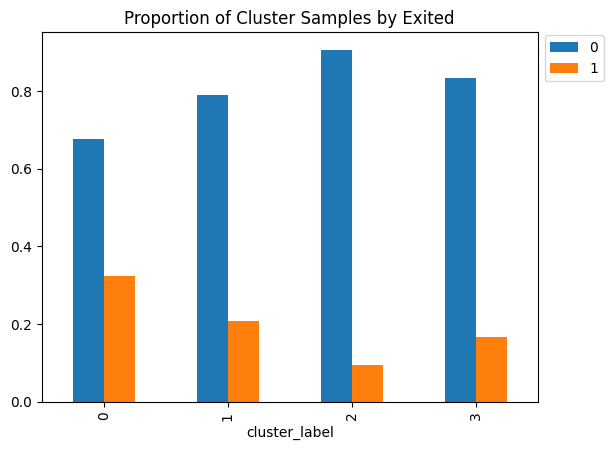

country        france  germany  spain
cluster_label                        
0                 0.0      1.0    0.0
1                 1.0      0.0    0.0
2                 1.0      0.0    0.0
3                 0.0      0.0    1.0


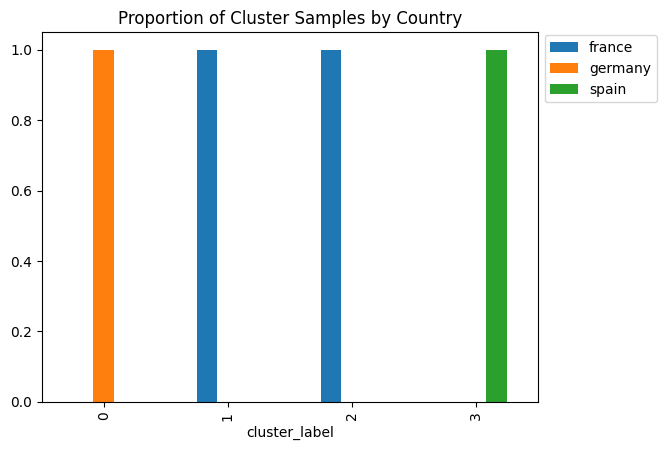

gender           female      male
cluster_label                    
0              0.475488  0.524512
1              0.445951  0.554049
2              0.458071  0.541929
3              0.439645  0.560355


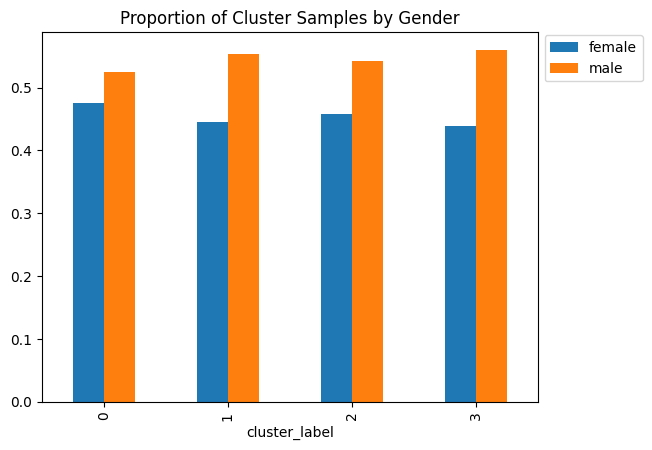

hascrcard             0         1
cluster_label                    
0              0.286170  0.713830
1              0.294476  0.705524
2              0.291808  0.708192
3              0.305208  0.694792


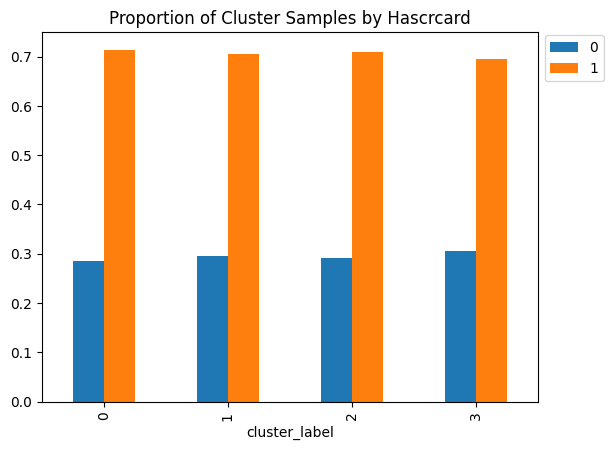

isactivemember         0         1
cluster_label                     
0               0.502591  0.497409
1               0.500169  0.499831
2               0.459040  0.540960
3               0.470327  0.529673


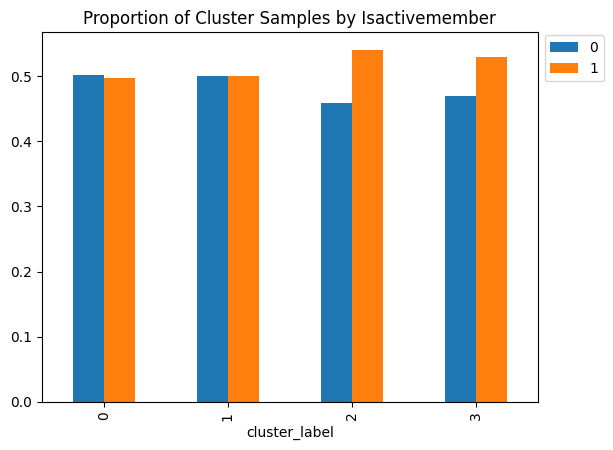

In [17]:
for col in categorical_cols:
    norm_counts = pd.crosstab(df_clustered[col], df_clustered["cluster_label"], normalize="columns").T
    print(norm_counts)
    norm_counts.plot(kind="bar")
    plt.title(f"Proportion of Cluster Samples by {col.title()}")
    plt.legend(bbox_to_anchor=[1, 1.01])
    plt.show()

### Visualize the clusters

In [18]:
from sklearn.decomposition import PCA

In [19]:
pca = PCA(2)
pca.fit(X_processed_scaled)

PCA(n_components=2)

In [20]:
pca.explained_variance_ratio_

array([0.1554941 , 0.12535425])

In [21]:
df_pca = pca.transform(X_processed_scaled)
df_pca.head()

,pca0,pca1
0,-1.399128,-0.582200
1,0.656222,1.714658
2,-0.769508,-0.734659
3,-1.682327,-0.258430
4,1.001920,1.521599


<Axes: xlabel='pca0', ylabel='pca1'>

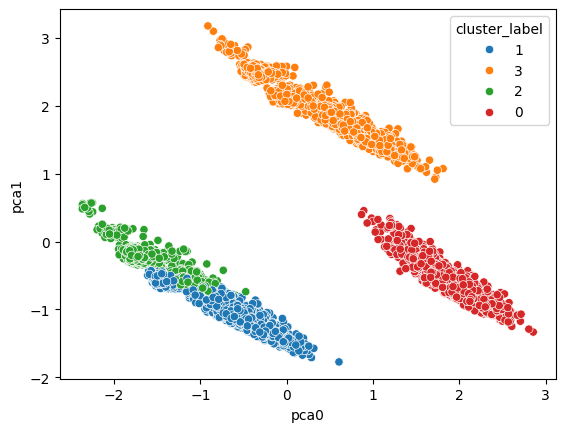

In [22]:
sns.scatterplot(x=df_pca["pca0"], y=df_pca["pca1"], hue=df_clustered["cluster_label"].astype(str))

### Check mutual info between exited and cluster_label

In [23]:
from sklearn.metrics import mutual_info_score

In [24]:
mutual_info_score(df_clustered["exited"], df_clustered["cluster_label"])

np.float64(0.020347311817967215)

## Key Takeaways

* The optimal number of clusters for the dataset is 4.

* Only balance and number of products columns seem to have a noticeable difference in average values.

* Customers in cluster 2 seem to have a very low balance compared to other customers.

* Customers in cluster 0 seem to have the highest churn rate, 32%, followed by customers in clusters 1, 3, and 2 with churn rates of 20%, 17%, and 9%, respectively.

* Customers in cluster 0 are from Germany, customers in cluster 1 and cluster 2 are from France, and customers in cluster 3 are from Spain.